In [2]:
#Part a) EDA
# i)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data_path="data.csv"
label_path="labels.csv"
df = pd.read_csv(data_path)
df = df.drop(df.columns[0], axis=1)

print (f"Data shape: {df.shape}")
df_labels=pd.read_csv(label_path)
classes = df_labels['Class'].unique()
for tumor_class in classes:
    print(f"{tumor_class}: {df_labels[df_labels['Class'] == tumor_class].shape[0]} samples")




Data shape: (801, 20531)
PRAD: 136 samples
LUAD: 141 samples
BRCA: 300 samples
KIRC: 146 samples
COAD: 78 samples


In [3]:
# ii)
print(df.describe())

           gene_0      gene_1      gene_2      gene_3      gene_4  gene_5  \
count  801.000000  801.000000  801.000000  801.000000  801.000000   801.0   
mean     0.026642    3.010909    3.095350    6.722305    9.813612     0.0   
std      0.136850    1.200828    1.065601    0.638819    0.506537     0.0   
min      0.000000    0.000000    0.000000    5.009284    8.435999     0.0   
25%      0.000000    2.299039    2.390365    6.303346    9.464466     0.0   
50%      0.000000    3.143687    3.127006    6.655893    9.791599     0.0   
75%      0.000000    3.883484    3.802534    7.038447   10.142324     0.0   
max      1.482332    6.237034    6.063484   10.129528   11.355621     0.0   

           gene_6      gene_7      gene_8      gene_9  ...  gene_20521  \
count  801.000000  801.000000  801.000000  801.000000  ...  801.000000   
mean     7.405509    0.499882    0.016744    0.013428  ...    5.896573   
std      1.108237    0.508799    0.133635    0.204722  ...    0.746399   
min      3

The approximate range is between 0 and 12

In [4]:
# iii) I had to drop columns with zero variance to avoid NaNs
valid_columns = df.std() > 0
df_filtered = df.loc[:, valid_columns]

print(f"Dropped {len(df.columns) - df_filtered.shape[1]} columns with zero variance.")
print(f"New data shape: {df_filtered.shape}") # Should be (801, 20264)

df_standardized = (df_filtered - df_filtered.mean()) / df_filtered.std()

print("Any NaNs remaining?", df_standardized.isna().sum().sum())

Dropped 267 columns with zero variance.
New data shape: (801, 20264)
Any NaNs remaining? 0


We standardize here to ensure every gene has a similar scale. By doing that, we avoid genes with larger ranges to influence the model more simply because it has a larger number than another gene and compare all features to their means and standard deviations

In [5]:
# b)
def pca_svd(X, k):

    X_mean = np.mean(X, axis=0)
    Xc = X - X_mean
        
    # Get dimensions
    N = Xc.shape[0]
    
    # Xc = U * Sigma * Vt
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    
    components = Vt[:k, :]
    projected = Xc @ components.T
    explained_variance = (S[:k] ** 2) / (N - 1)
    
    return components, projected, explained_variance

components, projected, explained_variance = pca_svd(df_standardized.values, 2)
print(f"Explained variance: {explained_variance}")
print(f"Components: {components}")

Explained variance: [2135.78129289 1773.95766758]
Components: [[ 0.00097941 -0.00235639 -0.00496579 ...  0.00233708  0.00195967
   0.00104891]
 [ 0.00230787 -0.00637287  0.00046648 ... -0.01493974 -0.00232062
   0.00100493]]


In [6]:
# c)
# i)
def pca_eig(X, k):

    X_mean = np.mean(X, axis=0)
    Xc = X - X_mean
    N, d = Xc.shape
    
    G = (Xc @ Xc.T) / (N - 1)
    
    eigvals, eigvecs = np.linalg.eigh(G)
    
    # Reverse the arrays
    eigvals = eigvals[::-1]
    eigvecs = eigvecs[:, ::-1]
    
    lambdas = eigvals[:k]
    U_k = eigvecs[:, :k]
    
    # Recover the principal axes
    V_k = (Xc.T @ U_k) / np.sqrt((N - 1) * lambdas)
    
    components = V_k.T
    projected = Xc @ V_k
    explained_variance = lambdas
    
    return components, projected, explained_variance

components, projected, explained_variance = pca_eig(df_standardized.values, 2)
print(f"Explained variance: {explained_variance}")
print(f"Components: {components}")

Explained variance: [2135.78129289 1773.95766758]
Components: [[-0.00097941  0.00235639  0.00496579 ... -0.00233708 -0.00195967
  -0.00104891]
 [-0.00230787  0.00637287 -0.00046648 ...  0.01493974  0.00232062
  -0.00100493]]


The results match each other very well: the variances are exactly the same and the principal components differ only by a factor of -1.

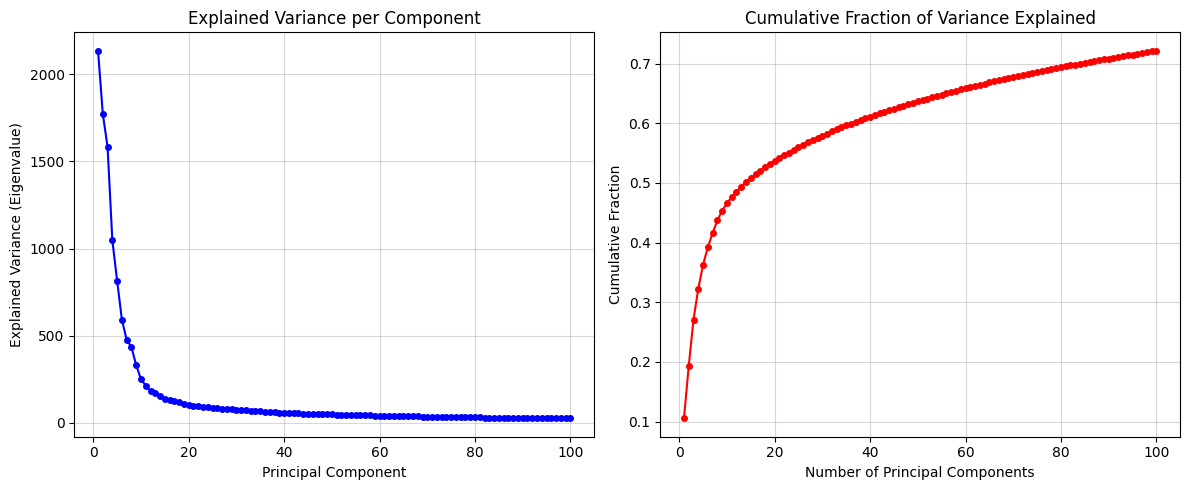

In [7]:
k = 100
X_data = df_standardized.values
components, projected, explained_variance = pca_eig(X_data, k=k)

total_variance = np.var(X_data, axis=0, ddof=1).sum()
fraction_explained = explained_variance / total_variance
cumulative_fraction = np.cumsum(fraction_explained)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Explained variance of each component (Scree Plot)
axes[0].plot(range(1, k + 1), explained_variance, marker='o', linestyle='-', markersize=4, color='b')
axes[0].set_title("Explained Variance per Component")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance (Eigenvalue)")
axes[0].grid(True, alpha=0.5)

# Cumulative fraction of variance explained
axes[1].plot(range(1, k + 1), cumulative_fraction, marker='o', linestyle='-', markersize=4, color='r')
axes[1].set_title("Cumulative Fraction of Variance Explained")
axes[1].set_xlabel("Number of Principal Components")
axes[1].set_ylabel("Cumulative Fraction")
axes[1].grid(True, alpha=0.5)

plt.tight_layout()
plt.show()


In [8]:
k_max = 800
components, projected, explained_variance = pca_eig(X_data, k=k_max)


fraction_explained = explained_variance / total_variance
cumulative_fraction = np.cumsum(fraction_explained)

if cumulative_fraction[-1] < 0.80:
    print(f"Error: Even at k={k_max}, the cumulative variance is only {cumulative_fraction[-1]:.2%}")
else:
    k_80 = np.argmax(cumulative_fraction >= 0.80) + 1
    print(f"Components needed to explain 80% of variance: {k_80}")

Components needed to explain 80% of variance: 183


This number is much smaller than the original 20531 genes. It shows that the vast majority of genes vary very little and we can get most of the variance from the most important 183 features

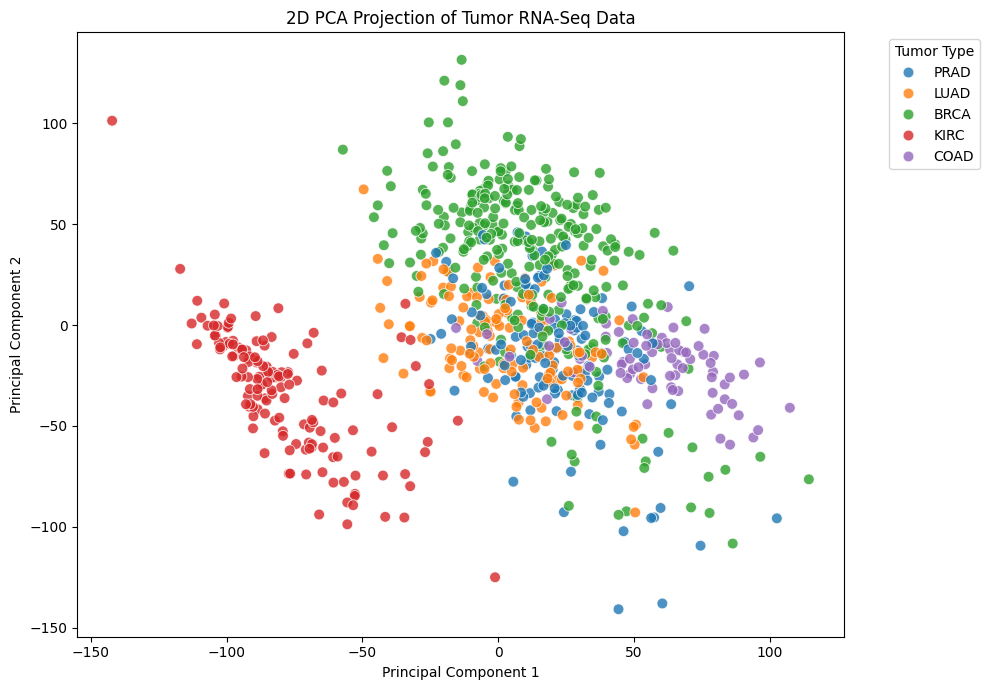

In [9]:
# e)
components, projected, explained_variance = pca_eig(X_data, k=2)

plot_df = pd.DataFrame({
    'PC1': projected[:, 0],
    'PC2': projected[:, 1],
    'Tumor_Type': df_labels['Class']  
})

# 4. Create the scatter plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=plot_df,
    x='PC1',
    y='PC2',
    hue='Tumor_Type',
    palette='tab10',  # Distinct colors for the 5 classes
    s=60,             # Marker size
    alpha=0.8,        # Slight transparency to see overlapping points
    edgecolor='w'
)

# Formatting
plt.title("2D PCA Projection of Tumor RNA-Seq Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="Tumor Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Tumors of the same type tend to cluster together. The most unique tumor (Kidney renal clear cell) is very well separated and the only carcinoma is relatevely well separated too. However, the 3 adenocarcinomas are entangled and hard to separated

In [ ]:
# f)
pc1 = components[0, :]
abs_loadings = np.abs(pc1)
top_10_indices = np.argsort(abs_loadings)[::-1][:10]
top_10_values = pc1[top_10_indices]

print("Top 10 Genes Driving PC1 (by absolute loading):")
print("-" * 40)
print(f"{'Gene Index':<12} | {'Loading Value'}")
print("-" * 40)
for idx, val in zip(top_10_indices, top_10_values):
    print(f"{idx:<12} | {val:.6f}")

Top 10 Genes Driving PC1 (by absolute loading):
----------------------------------------
Gene Index   | Loading Value
----------------------------------------
19595        | -0.019002
17106        | -0.018985
13465        | -0.018966
15127        | -0.018777
7021         | -0.018740
7009         | -0.018657
10765        | -0.018629
13483        | 0.018624
6533         | -0.018595
2286         | 0.018592


In [11]:
pc2 = components[1, :]
abs_loadings = np.abs(pc2)
top_10_indices = np.argsort(abs_loadings)[::-1][:10]
top_10_values = pc2[top_10_indices]

print("Top 10 Genes Driving PC2 (by absolute loading):")
print("-" * 40)
print(f"{'Gene Index':<12} | {'Loading Value'}")
print("-" * 40)
for idx, val in zip(top_10_indices, top_10_values):
    print(f"{idx:<12} | {val:.6f}")

Top 10 Genes Driving PC2 (by absolute loading):
----------------------------------------
Gene Index   | Loading Value
----------------------------------------
3610         | 0.020273
1220         | -0.019863
14671        | 0.019862
1008         | -0.019829
19232        | -0.019505
1111         | 0.019409
3601         | 0.019346
362          | 0.019225
11130        | -0.019222
19599        | -0.019133


The top genes for PC1 and PC2 are all different as expected. The combination of the different genes encode something together allowing us to reduce the dimentionallity (Eg: imune response is dictated by hundreds/thousands of genes combined)

/home/langone/EC146/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


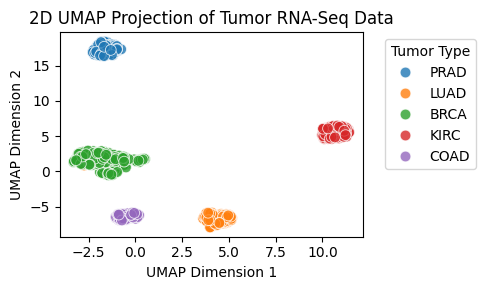

In [15]:
# g)
import umap
reducer = umap.UMAP(n_components=2, random_state=42)
embedding = reducer.fit_transform(X_data)

umap_df = pd.DataFrame({
    'UMAP1': embedding[:, 0],
    'UMAP2': embedding[:, 1],
    'Tumor_Type': df_labels['Class']  
})

plt.figure(figsize=(5, 3))
sns.scatterplot(
    data=umap_df,
    x='UMAP1',
    y='UMAP2',
    hue='Tumor_Type',
    palette='tab10',
    s=60,
    alpha=0.8,
    edgecolor='w'
)

plt.title("2D UMAP Projection of Tumor RNA-Seq Data")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(title="Tumor Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/home/langone/EC146/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


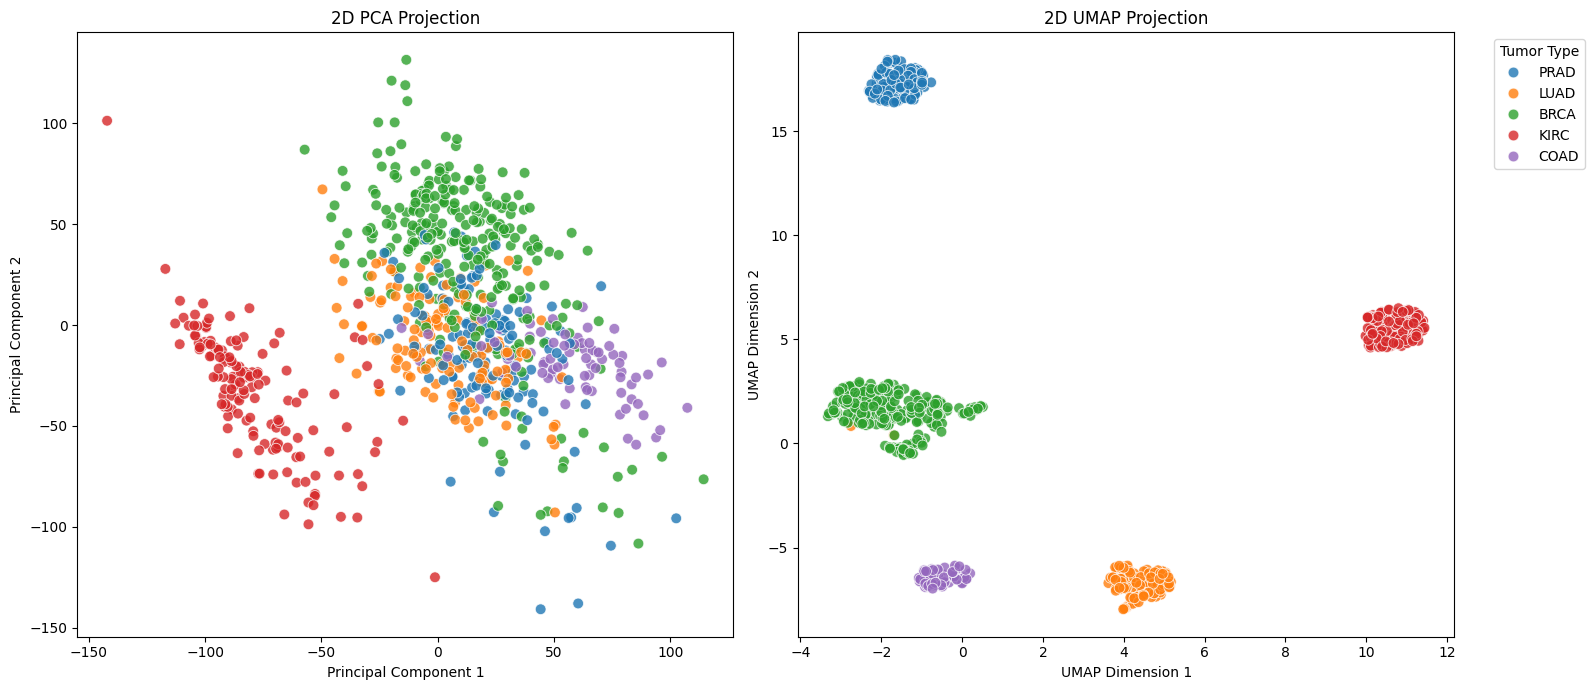

In [ ]:
# ii)
components, projected, explained_variance = pca_eig(X_data, k=2)
pca_df = pd.DataFrame({
    'PC1': projected[:, 0],
    'PC2': projected[:, 1],
    'Tumor_Type': df_labels['Class']  
})

reducer = umap.UMAP(n_components=2, random_state=42)
embedding = reducer.fit_transform(X_data)
umap_df = pd.DataFrame({
    'UMAP1': embedding[:, 0],
    'UMAP2': embedding[:, 1],
    'Tumor_Type': df_labels['Class']  
})
fig, axes = plt.subplots(1, 2, figsize=(16, 7))


sns.scatterplot(
    ax=axes[0],
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Tumor_Type',
    palette='tab10',
    s=60,
    alpha=0.8,
    edgecolor='w',
    legend=False  # Hide legend here to avoid duplicates
)
axes[0].set_title("2D PCA Projection")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")

sns.scatterplot(
    ax=axes[1],
    data=umap_df,
    x='UMAP1',
    y='UMAP2',
    hue='Tumor_Type',
    palette='tab10',
    s=60,
    alpha=0.8,
    edgecolor='w'
)
axes[1].set_title("2D UMAP Projection")
axes[1].set_xlabel("UMAP Dimension 1")
axes[1].set_ylabel("UMAP Dimension 2")

axes[1].legend(title="Tumor Type", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

UMAP does a much better job in separating all kinds of tumors from each other. Its non linearity allows much more flexibility than simply looking for the directions that conserve the most variance by making a similarity graph and conserving its structure.

/home/langone/EC146/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/langone/EC146/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/langone/EC146/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/langone/EC146/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/langone/EC146/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/langone/EC146/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs 

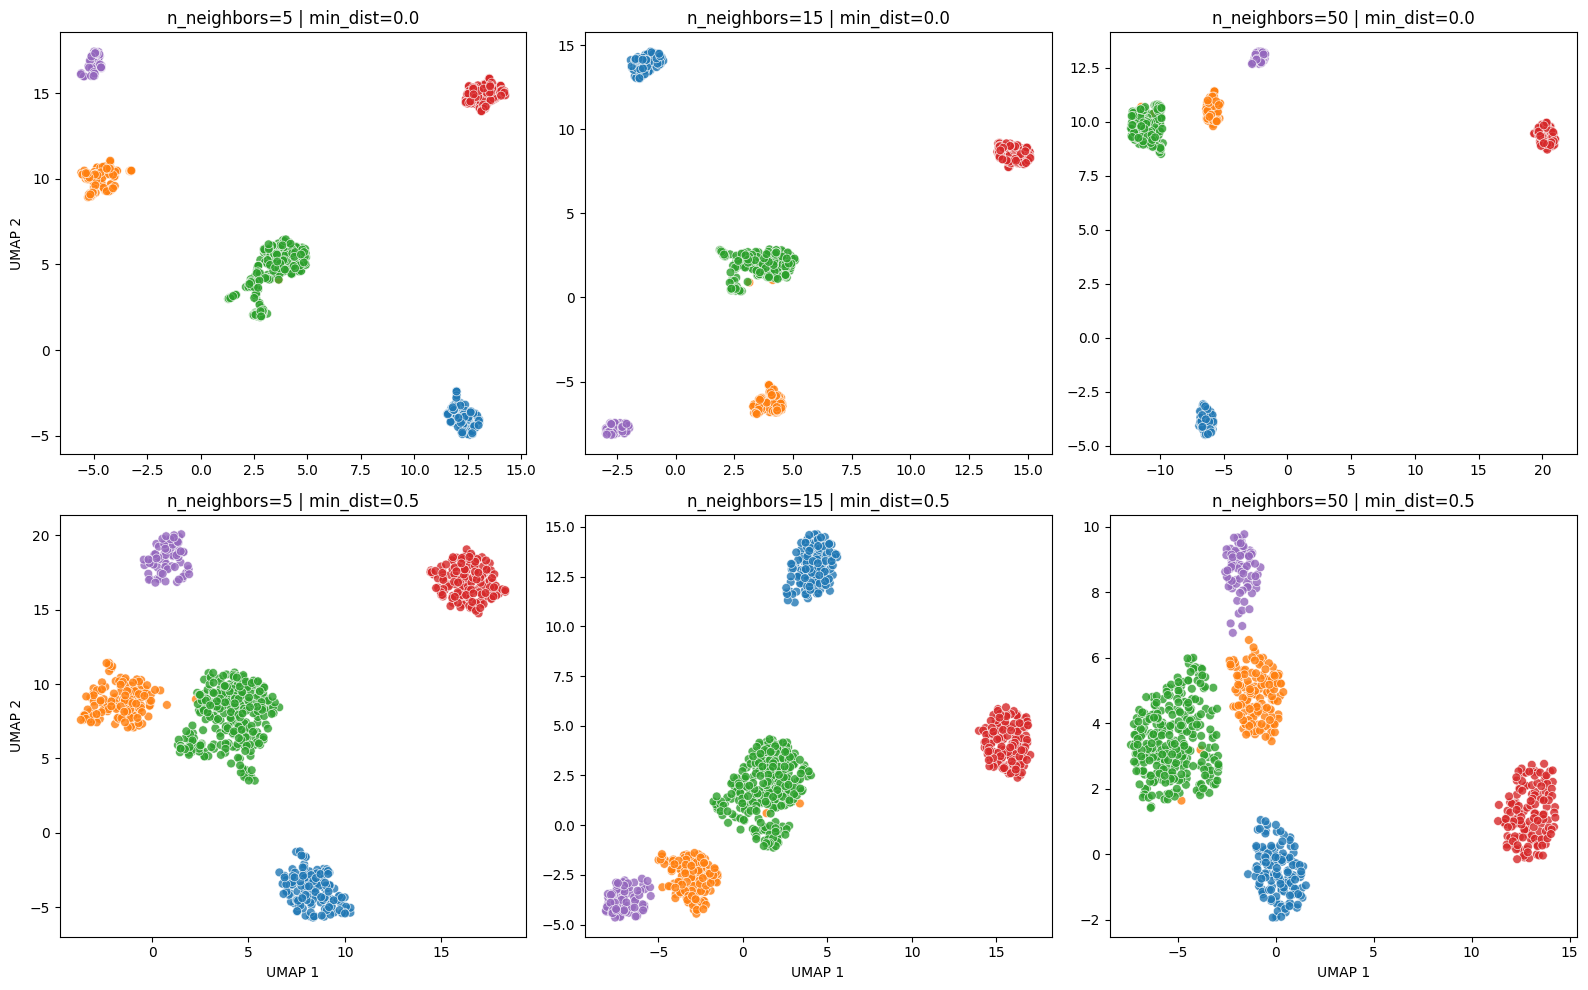

In [18]:
# h)
n_neighbors_list = [5, 15, 50]
min_dist_list = [0.0, 0.5]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))

# Loop through combinations
for i, min_dist in enumerate(min_dist_list):
    for j, n_neighbors in enumerate(n_neighbors_list):
        
        reducer = umap.UMAP(
            n_neighbors=n_neighbors, 
            min_dist=min_dist, 
            n_components=2, 
            random_state=42
        )
        embedding = reducer.fit_transform(X_data)
        
        temp_df = pd.DataFrame({
            'UMAP1': embedding[:, 0],
            'UMAP2': embedding[:, 1],
            'Tumor_Type': df_labels['Class']
        })
        
        ax = axes[i, j]
        sns.scatterplot(
            ax=ax,
            data=temp_df,
            x='UMAP1',
            y='UMAP2',
            hue='Tumor_Type',
            palette='tab10',
            s=40,          # Slightly smaller dots for grid view
            alpha=0.8,
            edgecolor='w',
            legend=False   # Hide individual legends to avoid clutter
        )
        
        ax.set_title(f"n_neighbors={n_neighbors} | min_dist={min_dist}")
        ax.set_xlabel("UMAP 1" if i == 1 else "")
        ax.set_ylabel("UMAP 2" if j == 0 else "")

handles, labels = axes[0, 0].get_legend_handles_labels()

plt.tight_layout()
plt.show()

Increasing the number of neighbors allows clusters to be close to each other and increasing the minimum distance increases the individual size of each cluster. I would ship the bottom right corner as its prioritizes global relations (instead of very local structure) and allows some variation within each cluster while conserving overall separability between clusters.  

In [ ]:
# i)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

y = df_labels['Class']


X_full_train, X_full_test, y_train, y_test = train_test_split(
    X_data, y, test_size=0.20, stratify=y, random_state=42
)

X_pca_train, X_pca_test, _, _ = train_test_split(
    projected, y, test_size=0.20, stratify=y, random_state=42
)

X_umap_train, X_umap_test, _, _ = train_test_split(
    embedding, y, test_size=0.20, stratify=y, random_state=42
)

clf_full = LogisticRegression(max_iter=2000, random_state=42)
clf_pca = LogisticRegression(max_iter=2000, random_state=42)
clf_umap = LogisticRegression(max_iter=2000, random_state=42)

# Full 20,531-gene vector
clf_full.fit(X_full_train, y_train)
y_pred_full = clf_full.predict(X_full_test)
acc_full = accuracy_score(y_test, y_pred_full)

# 2D PCA embedding
clf_pca.fit(X_pca_train, y_train)
y_pred_pca = clf_pca.predict(X_pca_test)
acc_pca = accuracy_score(y_test, y_pred_pca)

# 2D UMAP embedding
clf_umap.fit(X_umap_train, y_train)
y_pred_umap = clf_umap.predict(X_umap_test)
acc_umap = accuracy_score(y_test, y_pred_umap)

print("Logistic Regression Accuracies (Test Set):")
print("-" * 45)
print(f"Full 20,531-gene vector : {acc_full:.2%}")
print(f"2D PCA embedding        : {acc_pca:.2%}")
print(f"2D UMAP embedding       : {acc_umap:.2%}")

Logistic Regression Accuracies (Test Set):
---------------------------------------------
Full 20,531-gene vector : 98.14%
2D PCA embedding        : 63.98%
2D UMAP embedding       : 98.76%


UMAP comes very close to the full-feature baseline (note that it does slightly better, maybe due to data leakage as we used the entire dataset for UMAP and PCA). PCA is surprisingly very bad in comparison to the baseline. However, increasing PCA to k=10 would very likely increase accuracy as using more principal components would greatly increase the percentage of variance remaning from the original dataset.

h) I would recommend 2D UMAP embedding for the bioinformatics lab as it is fast to train, reduces computation, and achieves very good accuracy. Although, it has impressive accuracy, I would not recomend UMAP when biologists want to discover the specific genes that causes each type of tumor as we cannot easily extract that information from UMAP.